<a href="https://colab.research.google.com/github/HitenBangarwa/HitenMLlab/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [18]:
df = pd.read_csv("/content/apartments_for_rent_classified_10K.csv",
                 sep=';',
                 encoding='latin1',
                 engine='python',
                 on_bad_lines='skip')

df.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [19]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   category       10000 non-null  object 
 2   title          10000 non-null  object 
 3   body           10000 non-null  object 
 4   amenities      6451 non-null   object 
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  object 
 8   fee            10000 non-null  object 
 9   has_photo      10000 non-null  object 
 10  pets_allowed   5837 non-null   object 
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  object 
 13  price_type     10000 non-null  object 
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   object 
 16  cityname       9923 non-null   object 
 17  state          9923 non-null   object 
 18  latitud

In [20]:
df.describe()

,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
count,1.000000e+04,9966.000000,9993.000000,10000.000000,10000.000000,9990.000000,9990.000000,1.000000e+04
mean,5.623396e+09,1.380544,1.744021,1486.277500,945.810500,37.695162,-94.652247,1.574891e+09
std,7.021025e+07,0.615410,0.942354,1076.507968,655.755736,5.495851,15.759805,3.762395e+06
min,5.508654e+09,1.000000,0.000000,200.000000,101.000000,21.315500,-158.022100,1.568744e+09
25%,5.509248e+09,1.000000,1.000000,949.000000,649.000000,33.679850,-101.301700,1.568781e+09
50%,5.668610e+09,1.000000,2.000000,1270.000000,802.000000,38.809800,-93.651600,1.577358e+09
75%,5.668626e+09,2.000000,2.000000,1695.000000,1100.000000,41.349800,-82.209975,1.577359e+09
max,5.668663e+09,8.500000,9.000000,52500.000000,40000.000000,61.594000,-70.191600,1.577362e+09


In [21]:
df.columns

Index(['id', 'category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms',
       'currency', 'fee', 'has_photo', 'pets_allowed', 'price',
       'price_display', 'price_type', 'square_feet', 'address', 'cityname',
       'state', 'latitude', 'longitude', 'source', 'time'],
      dtype='object')

In [22]:
df_numeric = df.select_dtypes(include=[np.number])

df_numeric.head()

,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
0,5668626895,NaN,0.0,790,101,38.9057,-76.9861,1577359415
1,5664597177,NaN,1.0,425,106,37.9680,-87.6621,1577017063
2,5668626833,1.0,0.0,1390,107,38.8910,-77.0816,1577359410
3,5659918074,1.0,0.0,925,116,47.6160,-122.3275,1576667743
4,5668626759,NaN,0.0,880,125,38.8738,-77.1055,1577359401


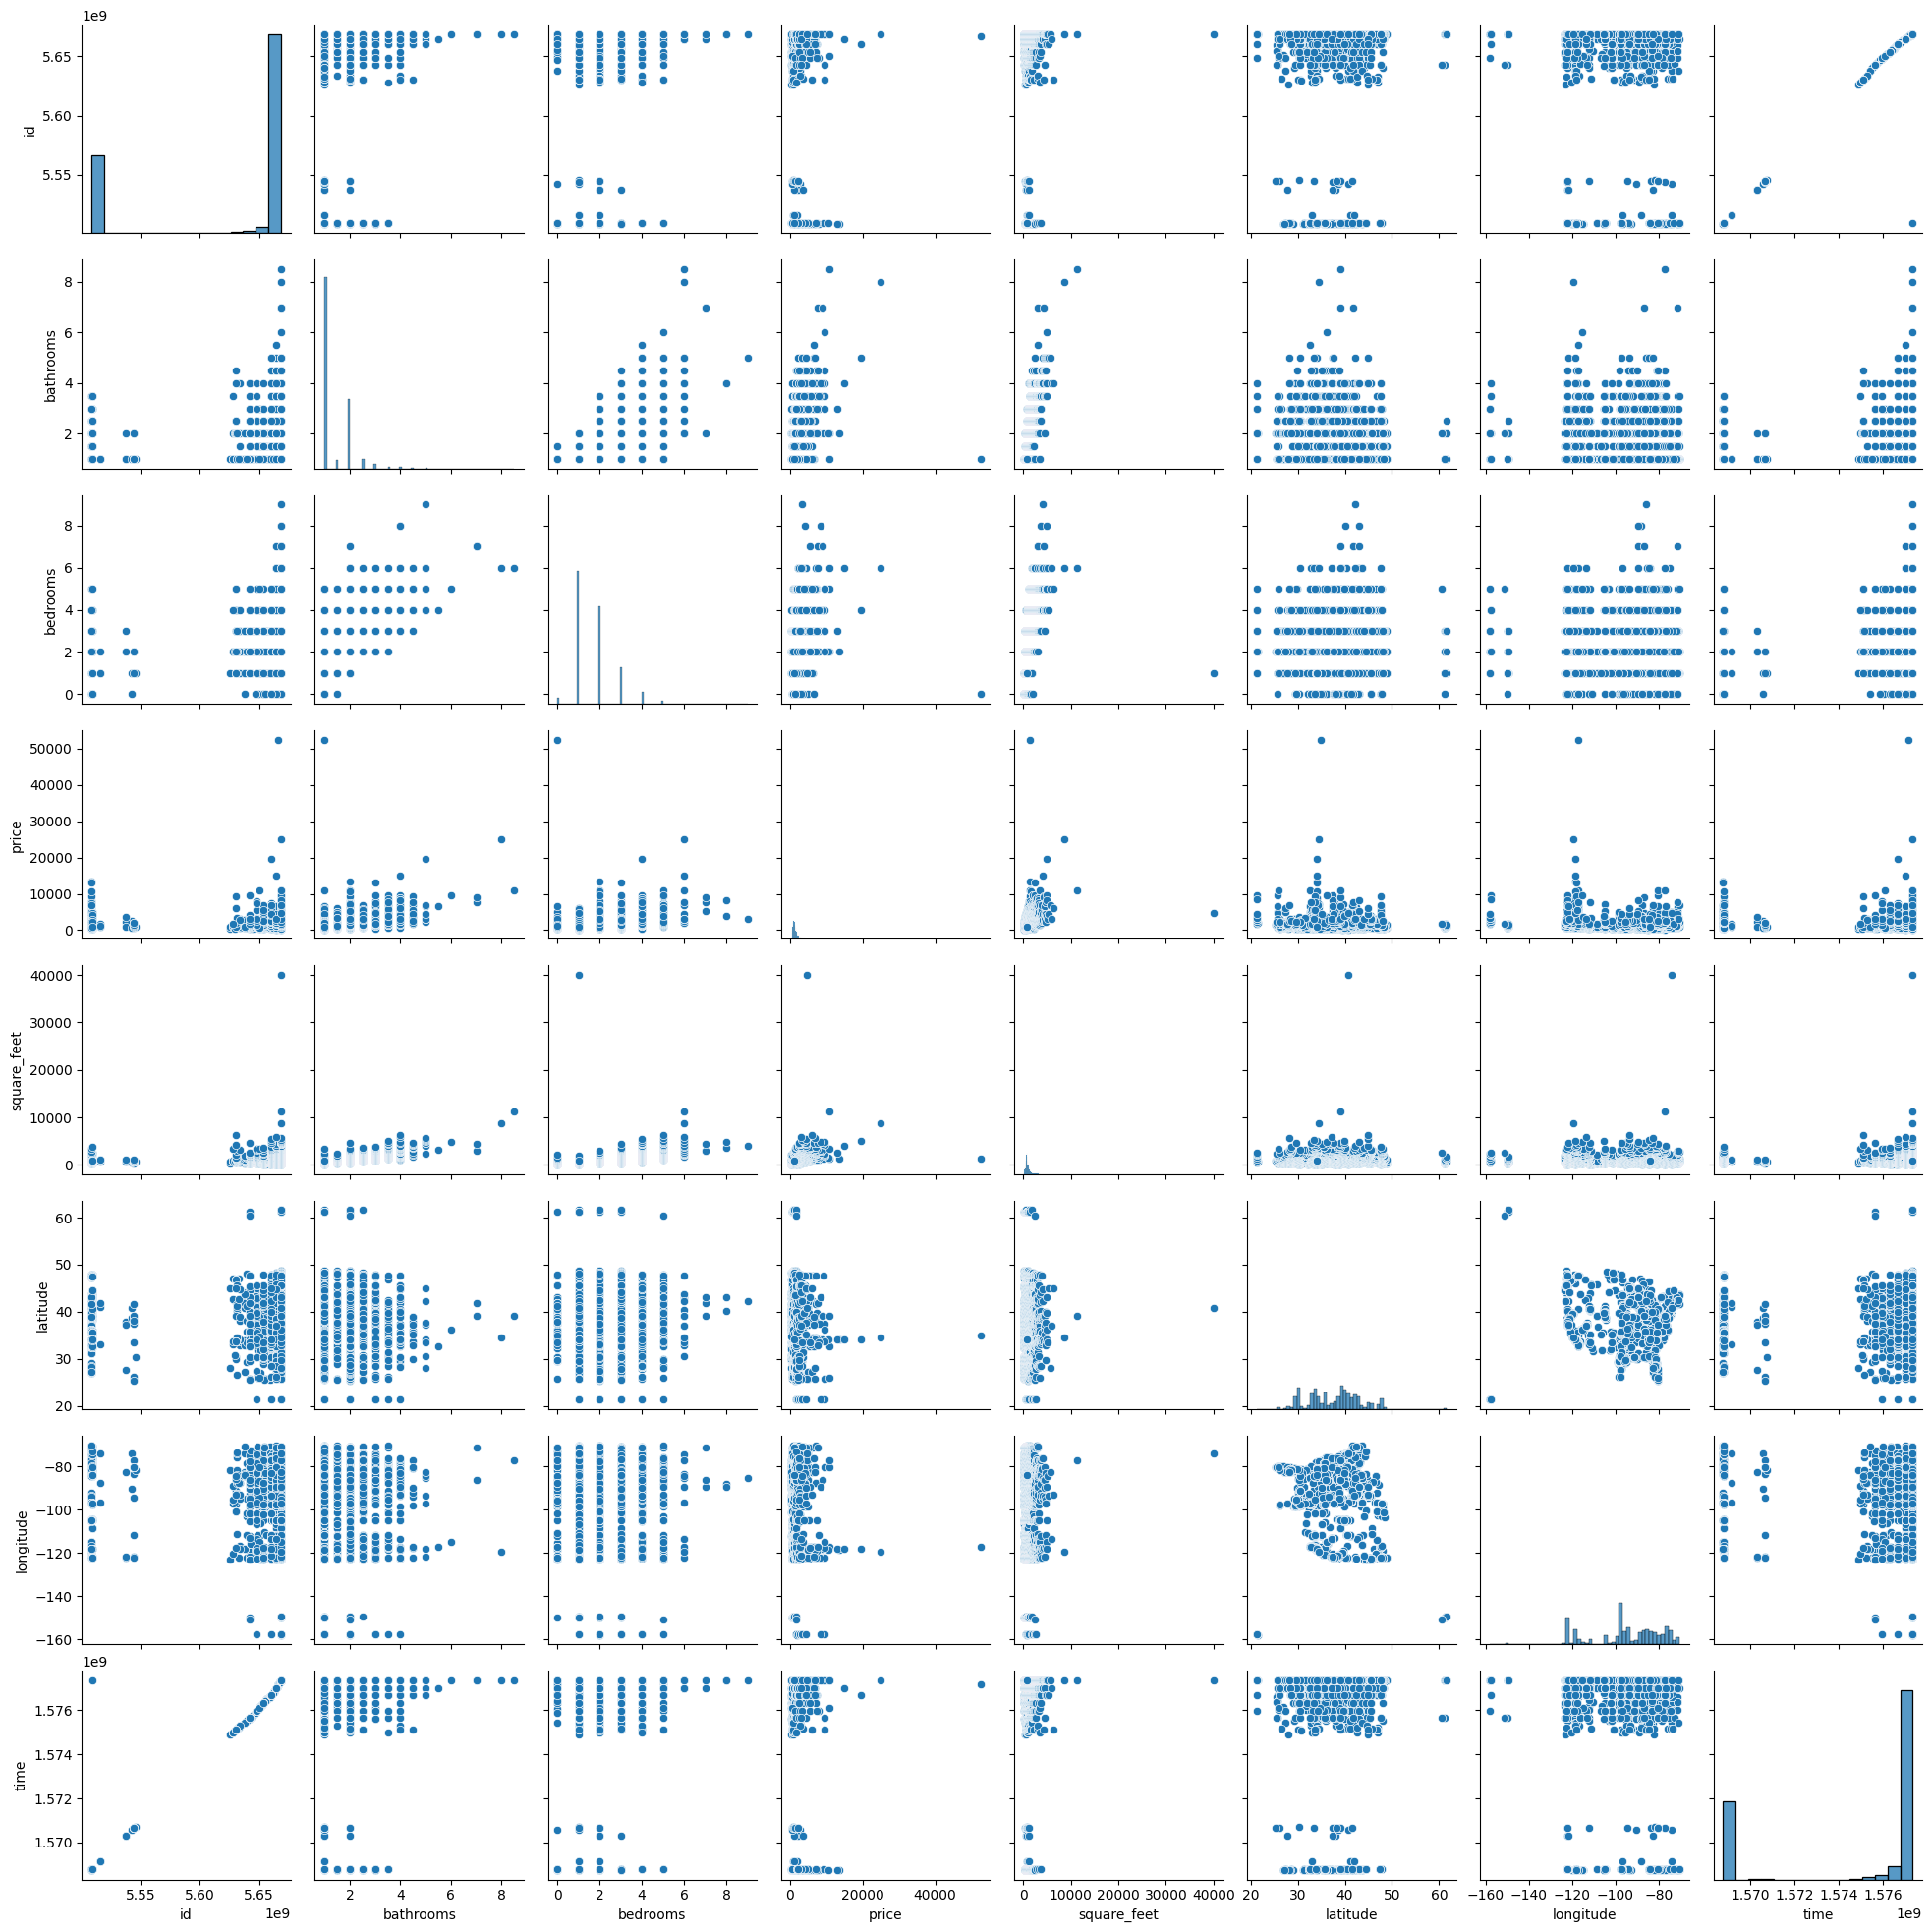

In [23]:
sns.pairplot(df_numeric)

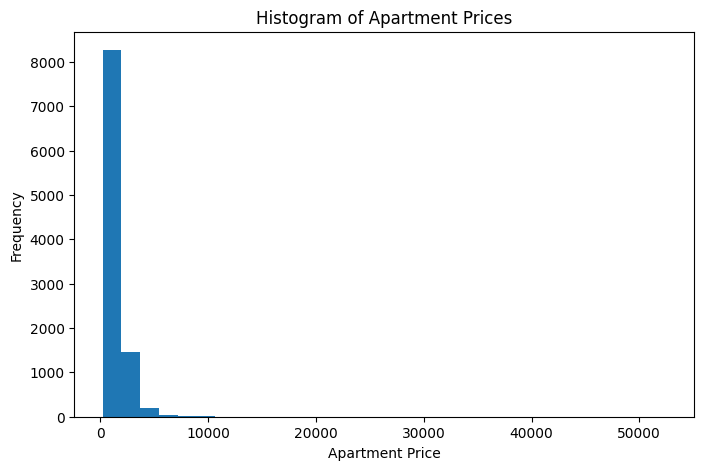

In [24]:
df['price'].plot.hist(bins=30, figsize=(8,5))

plt.xlabel("Apartment Price")
plt.title("Histogram of Apartment Prices")

plt.show()

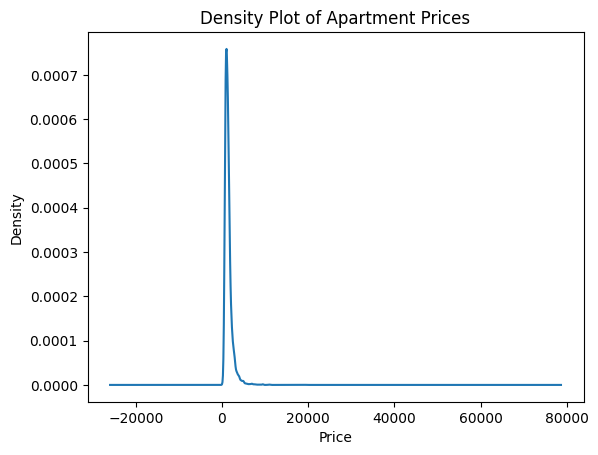

In [25]:
df['price'].plot.density()

plt.title("Density Plot of Apartment Prices")
plt.xlabel("Price")

plt.show()

In [26]:
corr_matrix = df_numeric.corr()

corr_matrix

,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
id,1.000000,-0.046812,0.034394,-0.021587,0.008193,-0.061859,-0.187835,0.999569
bathrooms,-0.046812,1.000000,0.705856,0.411655,0.796557,-0.049920,-0.000592,-0.048461
bedrooms,0.034394,0.705856,1.000000,0.306456,0.589194,0.024724,0.031177,0.032311
price,-0.021587,0.411655,0.306456,1.000000,0.390771,0.015075,-0.184250,-0.022298
square_feet,0.008193,0.796557,0.589194,0.390771,1.000000,-0.010772,0.021984,0.006829
latitude,-0.061859,-0.049920,0.024724,0.015075,-0.010772,1.000000,-0.106327,-0.062938
longitude,-0.187835,-0.000592,0.031177,-0.184250,0.021984,-0.106327,1.000000,-0.188804
time,0.999569,-0.048461,0.032311,-0.022298,0.006829,-0.062938,-0.188804,1.000000


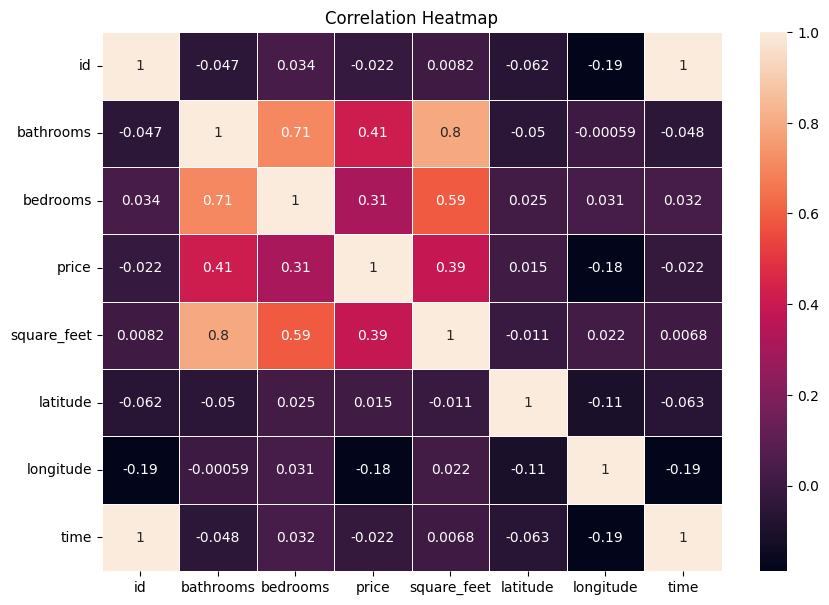

In [27]:
plt.figure(figsize=(10,7))

sns.heatmap(df_numeric.corr(),
            annot=True,
            linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

In [28]:
X = df_numeric.drop('price', axis=1)
y = df_numeric['price']

print("Feature set size:", X.shape)
print("Target set size:", y.shape)

Feature set size: (10000, 7)
Target set size: (10000,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

# Impute missing values with the mean
imputer = SimpleImputer(strategy='mean')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scale the imputed data
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

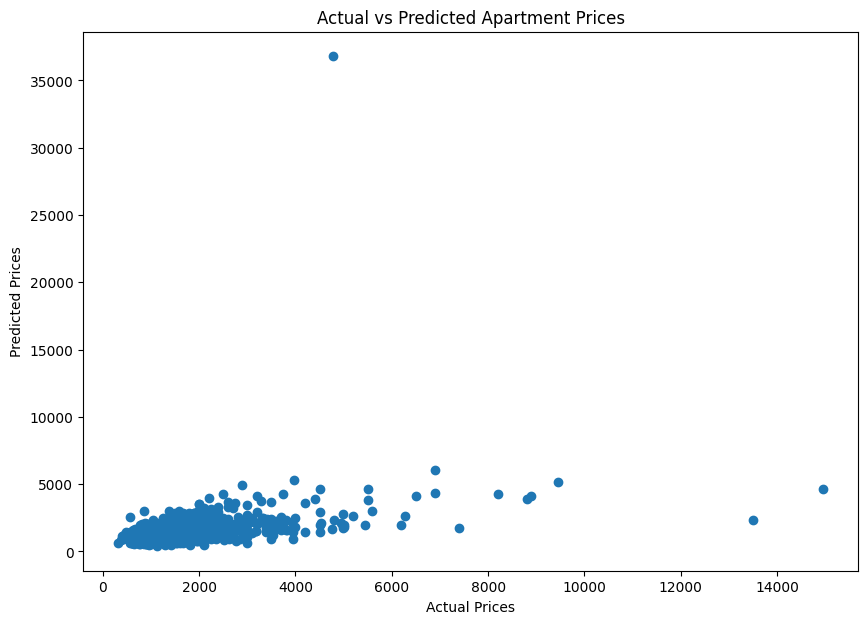

In [32]:
plt.figure(figsize=(10,7))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Apartment Prices")

plt.show()

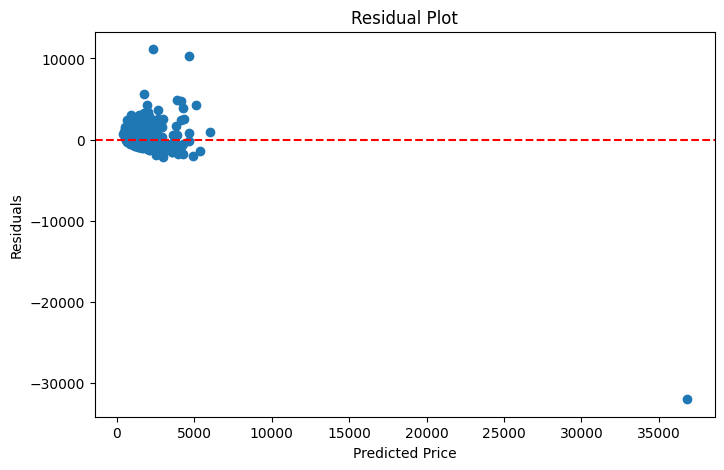

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(y_pred, y_test - y_pred)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.axhline(y=0, color='r', linestyle='--')

plt.title("Residual Plot")

plt.show()

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 516.4102201467497
MSE: 1119024.6446671141
RMSE: 1057.8396119767467
R2 Score: -0.2578896357828675


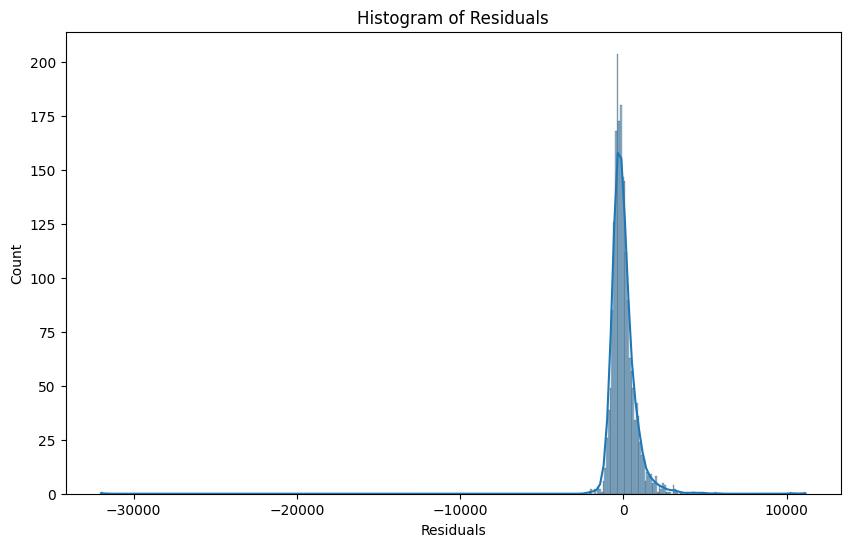

In [35]:
plt.figure(figsize=(10,6))

sns.histplot(y_test - y_pred, kde=True)

plt.title("Histogram of Residuals")
plt.xlabel("Residuals")

plt.show()